# Esercizio 2 - Lezione 4
## Classificazione con modello sequenziale

### Caricamento dati database MNIST

In [139]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

(train_img, train_label), (test_img, test_label) = tf.keras.datasets.fashion_mnist.load_data()

classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 
           'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

Plot di 36 immagini casuali

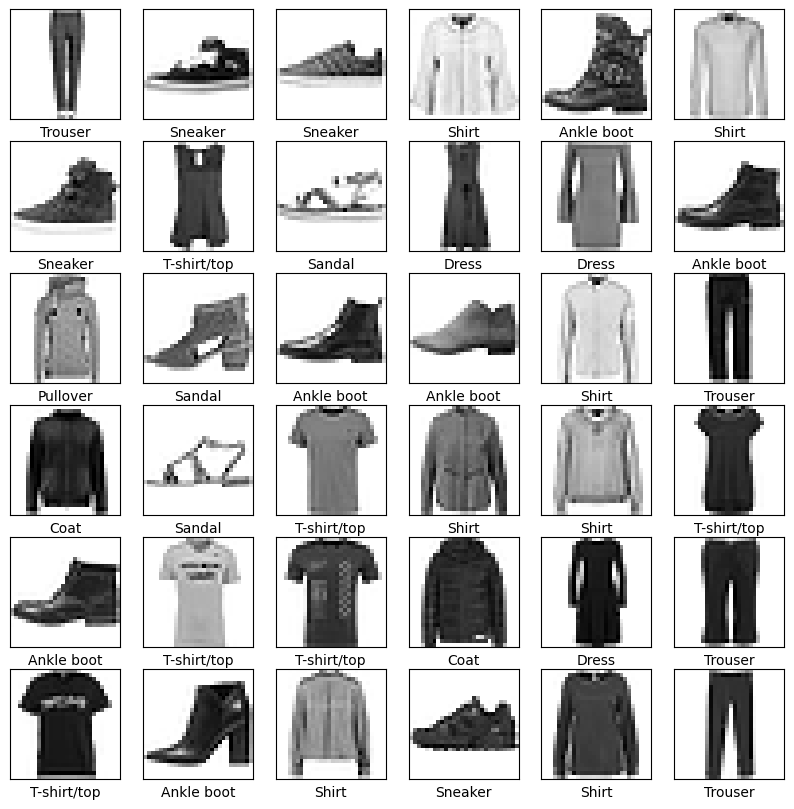

In [140]:
def plot_image(index, img, label):
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img[index], cmap='grey_r')
    plt.xlabel(classes[label[index]])

plt.figure(figsize=(10,10))

def plot_random_images(img, label):
    for i in range(1, 37):
        plt.subplot(6,6,i)
        index = np.random.randint(0,len(img))
        plot_image(index, img, label)

plot_random_images(train_img, train_label)

Normalizzazione delle immagini

In [141]:
norm = np.max(train_img)
train_img = train_img / norm
test_img = test_img / norm

### Creazione della rete neurale

In [142]:
model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Flatten(input_shape=(28,28)))
model.add(tf.keras.layers.Dense(128, activation='leaky_relu'))
model.add(tf.keras.layers.Dense(10, activation='softmax'))

model.summary()

/Users/francescospecchia/Desktop/UNI/DL/Repo/Lab/.venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_17 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Costruisco e alleno il modello in CPU perché è più veloce sulla mia macchina (MacBook Pro M1 Pro)

In [143]:
with tf.device('CPU'):
    model = tf.keras.models.Sequential()

    model.add(tf.keras.layers.Flatten(input_shape=(28,28)))
    model.add(tf.keras.layers.Dense(128, activation='leaky_relu'))
    model.add(tf.keras.layers.Dense(10, activation='softmax'))

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
            metrics=['accuracy'],
            loss=tf.keras.losses.sparse_categorical_crossentropy)
    
    history = model.fit(train_img, train_label, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8233 - loss: 0.5021
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8598 - loss: 0.3867
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8719 - loss: 0.3531
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8790 - loss: 0.3313
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8840 - loss: 0.3146
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8897 - loss: 0.3005
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8939 - loss: 0.2903
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8968 - loss: 0.2820
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8993 - loss: 0.2732
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 987us/step - accuracy: 0.9016 - loss: 0.2642


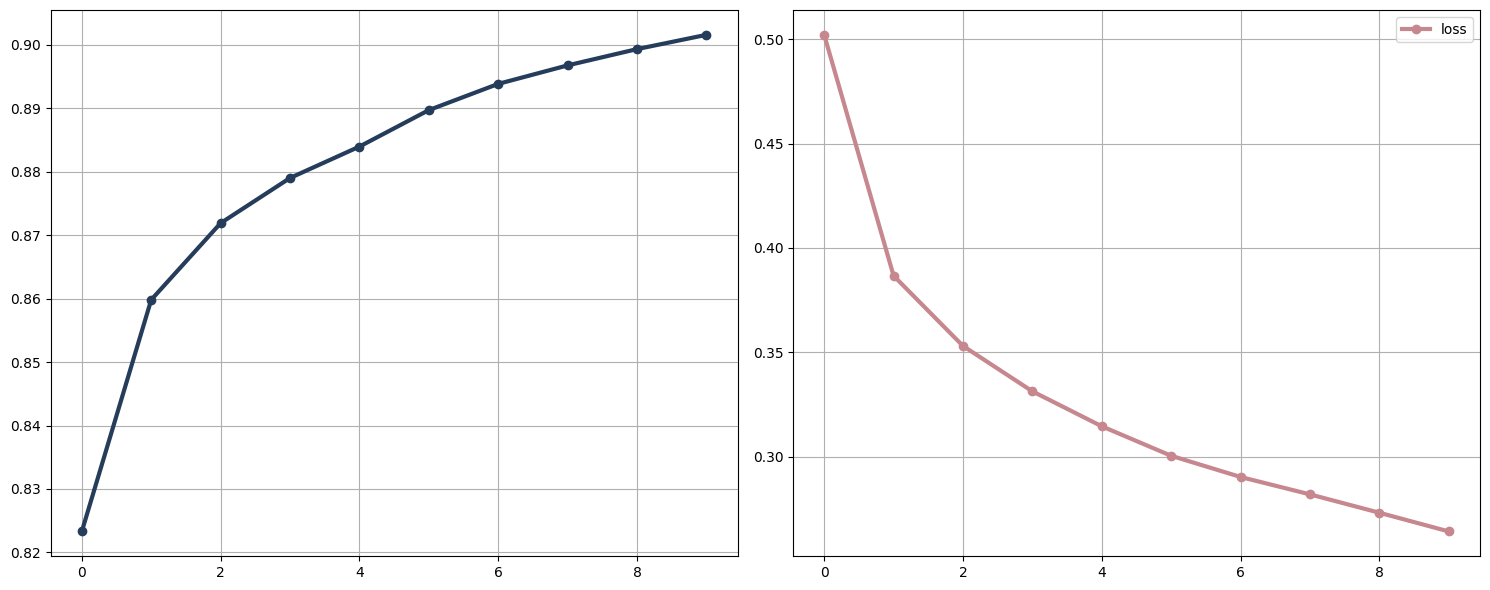

In [144]:
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.grid('both','both')
plt.plot(history.epoch, history.history['accuracy'], '-o', label='Accuracy',color='#253D5B',linewidth=3)
plt.subplot(1,2,2)
plt.plot(history.epoch, history.history['loss'], '-o' ,label='loss', color='#C6878F', linewidth=3)
plt.legend()
plt.grid('both','both')
plt.tight_layout()

In [145]:
(test_loss, test_acc) = model.evaluate(test_img, test_label)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8789 - loss: 0.3425


In [146]:
print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_acc}')

Test Loss: 0.3425087034702301
Test Accuracy: 0.8788999915122986


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


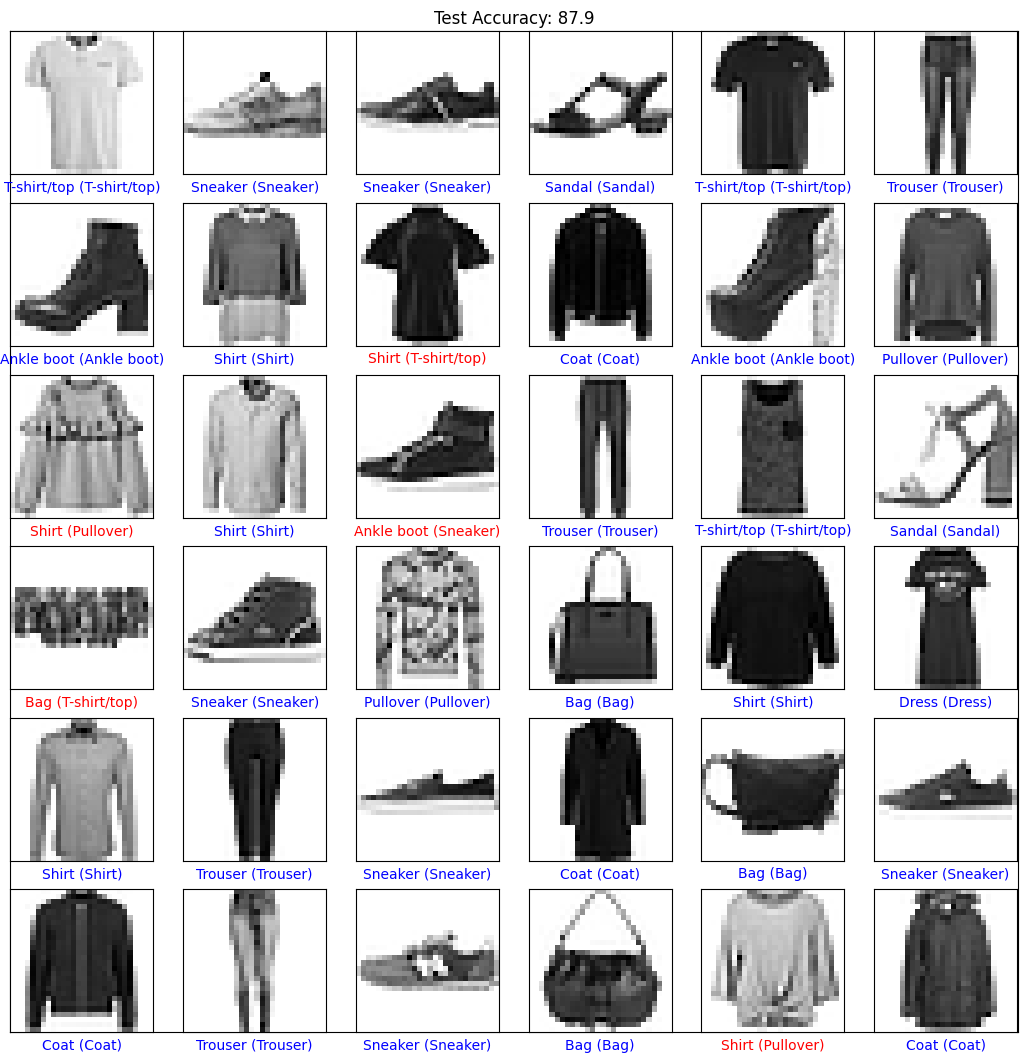

In [147]:
predictions = model.predict(test_img)

plt.figure(figsize=(13,13))
plt.title(f'Test Accuracy: {100*test_acc:.1f}')
plt.xticks([])
plt.yticks([])

index = np.random.randint(0, len(test_img-37))
k = 1
for i in range(index, index + 36):
    plt.subplot(6,6,k)
    plt.xticks([])
    plt.yticks([])

    plt.xlabel(f'{classes[np.argmax(predictions[i])]} ({classes[test_label[i]]})', 
               color=('blue' if np.argmax(predictions[i]) == test_label[i] else 'red'))
    plt.imshow(test_img[i], cmap='grey_r')
    k += 1